# Task 11: Comparative Analysis of Classification Models

**PKCERT AI & Software Development Internship** &nbsp;|&nbsp; Author: Abdullah Amir

This notebook builds **Logistic Regression**, **Random Forest** and an **SVM** on one
common dataset, trains and tests all three on exactly the same data, and compares them
on accuracy, precision, recall, F1 and confusion matrices.

The dataset is **UCI's Predict Students' Dropout and Academic Success**: real records
for 4,424 students at a Portuguese university, where the job is to predict whether a
student will **drop out**, stay **enrolled**, or **graduate**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A — Dataset Selection & Preparation

**The data.** 4,424 students, 36 features, and one three-way target. The features cover
four kinds of information gathered at or after enrolment:

- **Demographics:** age, gender, marital status, nationality, displaced status.
- **Family background:** the mother's and father's qualifications and occupations.
- **Admission route:** application mode and order, the course applied for, previous
  qualification and its grade, admission grade.
- **Academic performance:** for each of the first two semesters, how many curricular
  units the student enrolled in, sat evaluations for, **passed**, and their average
  grade. Plus financial signals: scholarship holder, debtor, tuition fees up to date.

**The target** is `Target`: `Dropout`, `Enrolled` (still studying, no outcome yet) or
`Graduate`. This is a genuine three-class problem, and the middle class is the awkward
one, which turns out to be the whole story of this notebook.

In [2]:
df = pd.read_csv("students.csv")
print("Shape:", df.shape, "| missing values:", int(df.isna().sum().sum()))
print()
print(df["Target"].value_counts().to_string())
print()
print((df["Target"].value_counts(normalize=True) * 100).round(1).to_string())
df.head()

Shape: (4424, 37) | missing values: 0

Target
Graduate    2209
Dropout     1421
Enrolled     794

Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Preprocessing.** No missing values, so the real work is deciding what each column
*means*. Two things need care.

1. **Some "numbers" are not numbers.** Columns like `Course`, `Application mode` and
   `Mother's occupation` are stored as integer *codes*. Left as-is, a linear model
   would read them as quantities and conclude that "Course 12 > Course 3", which is
   nonsense. These get **one-hot encoded** instead.
2. **Scaling.** Age, grades and unit counts live on very different scales. Logistic
   Regression and especially the SVM care a lot about this; the Random Forest does not,
   since a tree just asks "is this value above a threshold?". Scaling is harmless to
   the forest and essential to the other two.

Both steps go in a single `ColumnTransformer`, wrapped in a `Pipeline` with each model.
That matters for fairness *and* for correctness: the scaler and encoder are fit on the
training fold only, so nothing leaks from the test set.

In [3]:
CATEGORICAL = ["Marital status", "Application mode", "Course",
               "Previous qualification", "Nacionality",
               "Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]

y = df["Target"]
X = df.drop(columns=["Target"])
numeric = [c for c in X.columns if c not in CATEGORICAL]
print(f"{len(numeric)} numeric/binary features | {len(CATEGORICAL)} categorical to encode")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

27 numeric/binary features | 9 categorical to encode
Train: 3539 rows | Test: 885 rows


In [4]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
n_out = preprocess.fit(X_train).transform(X_train.head(1)).shape[1]
print(f"After one-hot encoding: {X_train.shape[1]} columns -> {n_out} model features")

LABELS = ["Dropout", "Enrolled", "Graduate"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

After one-hot encoding: 36 columns -> 236 model features


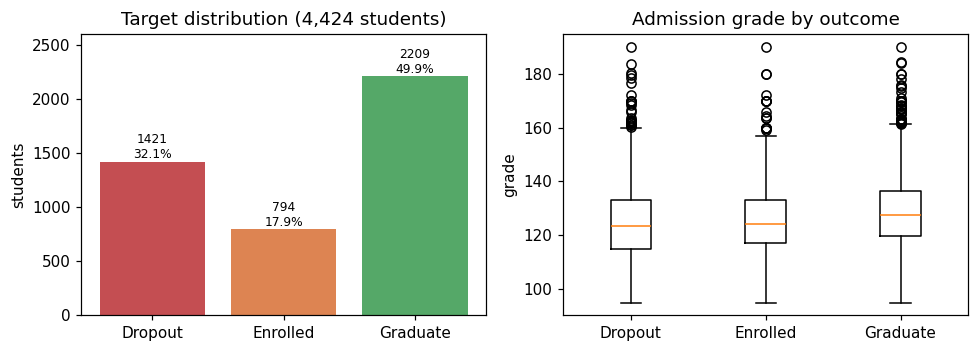

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
counts = df["Target"].value_counts().reindex(LABELS)
ax[0].bar(LABELS, counts.values, color=["#C44E52", "#DD8452", "#55A868"])
ax[0].set_title("Target distribution (4,424 students)"); ax[0].set_ylabel("students")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 30, f"{v}\n{v/len(df)*100:.1f}%", ha="center", fontsize=8)
ax[0].set_ylim(0, 2600)
data = [df.loc[df["Target"] == t, "Admission grade"] for t in LABELS]
ax[1].boxplot(data, tick_labels=LABELS)
ax[1].set_title("Admission grade by outcome"); ax[1].set_ylabel("grade")
fig.tight_layout(); plt.show()

Two useful observations. The classes are **imbalanced**: `Enrolled` is only 17.9% of
students, half the size of `Dropout`. And the admission grade barely separates the
three groups, the boxes almost completely overlap, so whatever signal exists is not
in how students *started*.

It is in how they *performed*:

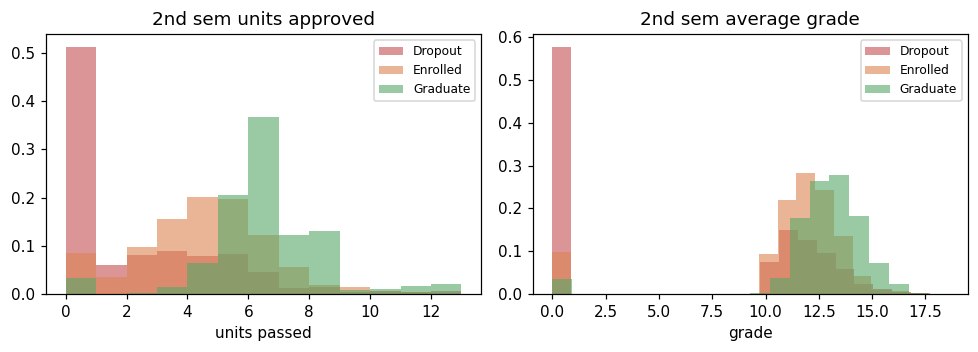

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
for t, c in zip(LABELS, ["#C44E52", "#DD8452", "#55A868"]):
    ax[0].hist(df.loc[df["Target"] == t, "Curricular units 2nd sem (approved)"],
               bins=range(0, 14), alpha=0.6, label=t, color=c, density=True)
ax[0].set_title("2nd sem units approved"); ax[0].set_xlabel("units passed"); ax[0].legend(fontsize=8)
for t, c in zip(LABELS, ["#C44E52", "#DD8452", "#55A868"]):
    ax[1].hist(df.loc[df["Target"] == t, "Curricular units 2nd sem (grade)"],
               bins=20, alpha=0.6, label=t, color=c, density=True)
ax[1].set_title("2nd sem average grade"); ax[1].set_xlabel("grade"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

There it is. Dropouts pile up at **zero units passed**, graduates cluster at five or
six. That single feature carries most of the predictive power, and notice that
`Enrolled` students sit *between* the two, overlapping both. That overlap is why the
middle class is so hard, and it is a property of the data, not of any model.

### One helper, three models

Every model goes through the **same pipeline, same split, same metrics**, which is what
makes this a fair comparison rather than three separate experiments.

We report **macro** averages for precision, recall and F1. Macro treats all three
classes as equally important regardless of size, so a model cannot look good by
nailing the big `Graduate` class and ignoring the small `Enrolled` one. That choice
does a lot of work later.

In [7]:
def build_and_eval(name, clf):
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    res = dict(name=name, pipe=pipe,
               acc=accuracy_score(y_test, pred),
               pre=precision_score(y_test, pred, average="macro"),
               rec=recall_score(y_test, pred, average="macro"),
               f1=f1_score(y_test, pred, average="macro"),
               f1w=f1_score(y_test, pred, average="weighted"),
               cm=confusion_matrix(y_test, pred, labels=LABELS),
               rec_per=recall_score(y_test, pred, average=None, labels=LABELS))
    cvs = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    res["cv"], res["cv_std"] = cvs.mean(), cvs.std()
    print(f"=== {name} ===")
    print(f"Accuracy {res['acc']:.4f} | Macro Precision {res['pre']:.4f} | "
          f"Macro Recall {res['rec']:.4f} | Macro F1 {res['f1']:.4f}")
    print(f"5-fold CV macro F1: {res['cv']:.4f} (std {res['cv_std']:.4f})\n")
    print(classification_report(y_test, pred, digits=3))
    return res

## Part B — Model Development

### B1. Logistic Regression

A **linear** model. It takes a weighted sum of the features and pushes it through a
softmax to get a probability per class, learning the weights by maximising the
likelihood of the observed outcomes. It can only draw straight boundaries between
classes, which sounds like a serious limitation and turns out not to be.

In [8]:
logreg = build_and_eval("Logistic Regression",
                        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))

=== Logistic Regression ===
Accuracy 0.7672 | Macro Precision 0.7122 | Macro Recall 0.6847 | Macro F1 0.6930
5-fold CV macro F1: 0.7012 (std 0.0121)

              precision    recall  f1-score   support

     Dropout      0.783     0.750     0.766       284
    Enrolled      0.544     0.390     0.454       159
    Graduate      0.810     0.914     0.859       442

    accuracy                          0.767       885
   macro avg      0.712     0.685     0.693       885
weighted avg      0.753     0.767     0.756       885



### B2. Random Forest

An **ensemble** of 300 decision trees. Each tree trains on a bootstrap sample of the
rows and considers only a random subset of features at each split, so the trees make
different mistakes and averaging their votes cancels much of the noise. It captures
non-linear patterns and feature interactions for free, and needs no scaling.

In [9]:
rf = build_and_eval("Random Forest",
                    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                           n_jobs=-1))

=== Random Forest ===
Accuracy 0.7672 | Macro Precision 0.7188 | Macro Recall 0.6572 | Macro F1 0.6625
5-fold CV macro F1: 0.6720 (std 0.0057)

              precision    recall  f1-score   support

     Dropout      0.790     0.768     0.779       284
    Enrolled      0.588     0.252     0.352       159
    Graduate      0.778     0.952     0.857       442

    accuracy                          0.767       885
   macro avg      0.719     0.657     0.663       885
weighted avg      0.748     0.767     0.741       885



### B3. Support Vector Machine

An SVM finds the boundary that separates classes with the widest **margin**, with only
the **support vectors** on the edge of that gap deciding where it lands. The **RBF
kernel** lets that boundary bend into non-linear shapes. It is the most
scaling-sensitive of the three, which the shared pipeline already handles.

In [10]:
svm = build_and_eval("SVM (RBF kernel)",
                     SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
results = [logreg, rf, svm]

=== SVM (RBF kernel) ===
Accuracy 0.7605 | Macro Precision 0.7086 | Macro Recall 0.6732 | Macro F1 0.6839
5-fold CV macro F1: 0.6898 (std 0.0060)

              precision    recall  f1-score   support

     Dropout      0.819     0.715     0.763       284
    Enrolled      0.522     0.377     0.438       159
    Graduate      0.785     0.928     0.851       442

    accuracy                          0.760       885
   macro avg      0.709     0.673     0.684       885
weighted avg      0.749     0.760     0.748       885



## Part C — Model Evaluation & Comparison

### The comparison table

In [11]:
summary = pd.DataFrame({
    "Accuracy": [r["acc"] for r in results],
    "Precision (macro)": [r["pre"] for r in results],
    "Recall (macro)": [r["rec"] for r in results],
    "F1 (macro)": [r["f1"] for r in results],
    "F1 (weighted)": [r["f1w"] for r in results],
    "CV F1 (std)": [f"{r['cv']:.3f} ({r['cv_std']:.3f})" for r in results],
}, index=[r["name"] for r in results])
summary.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),CV F1 (std)
Logistic Regression,0.7672,0.7122,0.6847,0.6930,0.7563,0.701 (0.012)
Random Forest,0.7672,0.7188,0.6572,0.6625,0.7410,0.672 (0.006)
SVM (RBF kernel),0.7605,0.7086,0.6732,0.6839,0.7484,0.690 (0.006)


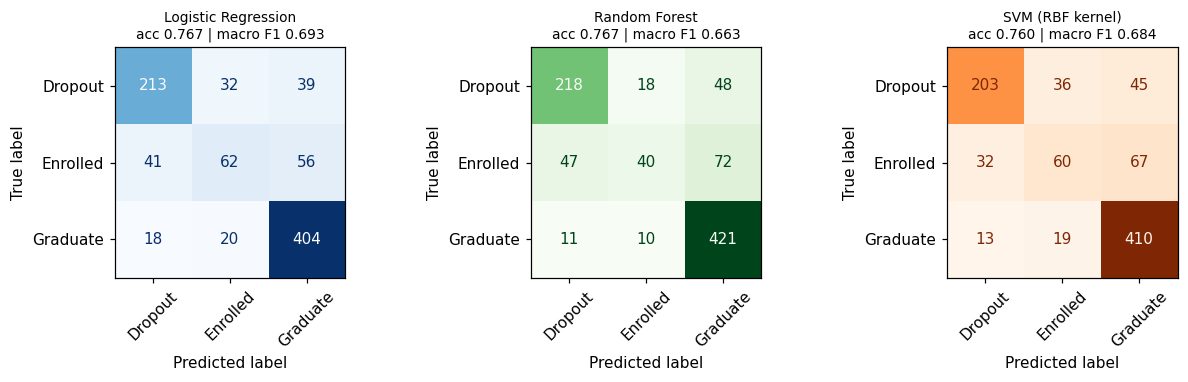

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
for a, r, cmap in zip(axes, results, ["Blues", "Greens", "Oranges"]):
    ConfusionMatrixDisplay(r["cm"], display_labels=LABELS).plot(
        ax=a, cmap=cmap, colorbar=False, values_format="d")
    a.set_title(f"{r['name']}\nacc {r['acc']:.3f} | macro F1 {r['f1']:.3f}", fontsize=9)
    a.tick_params(axis="x", rotation=45)
fig.tight_layout(); plt.show()

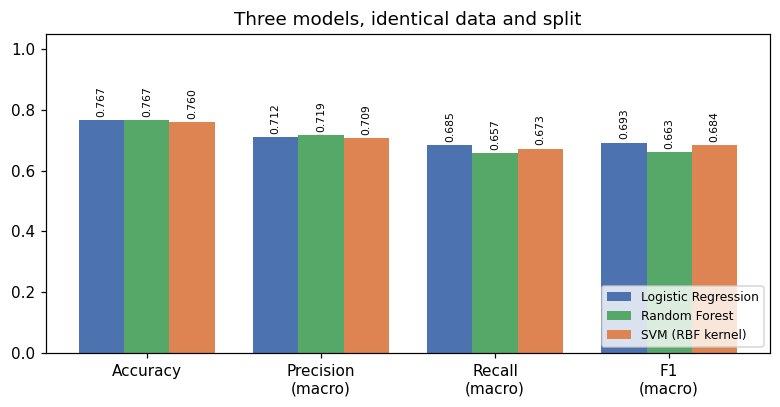

In [13]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors = ["#4C72B0", "#55A868", "#DD8452"]
x = np.arange(len(metrics)); w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for i, (r, c) in enumerate(zip(results, colors)):
    vals = [r["acc"], r["pre"], r["rec"], r["f1"]]
    b = ax.bar(x + (i - 1) * w, vals, w, label=r["name"], color=c)
    ax.bar_label(b, fmt="%.3f", padding=2, fontsize=7, rotation=90)
ax.set_xticks(x, ["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"])
ax.set_ylim(0, 1.05); ax.set_title("Three models, identical data and split")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

### Where the models actually differ

**Accuracy hides the whole story.** Logistic Regression and Random Forest tie at
*exactly* 0.7672. If we stopped at accuracy we would call it a dead heat and move on.
Macro F1 tells a different story: 0.693 for Logistic Regression against 0.663 for the
forest. The per-class recall shows why.

In [14]:
per_class = pd.DataFrame({r["name"]: r["rec_per"] for r in results}, index=LABELS)
per_class.round(3)

,Logistic Regression,Random Forest,SVM (RBF kernel)
Dropout,0.750,0.768,0.715
Enrolled,0.390,0.252,0.377
Graduate,0.914,0.952,0.928


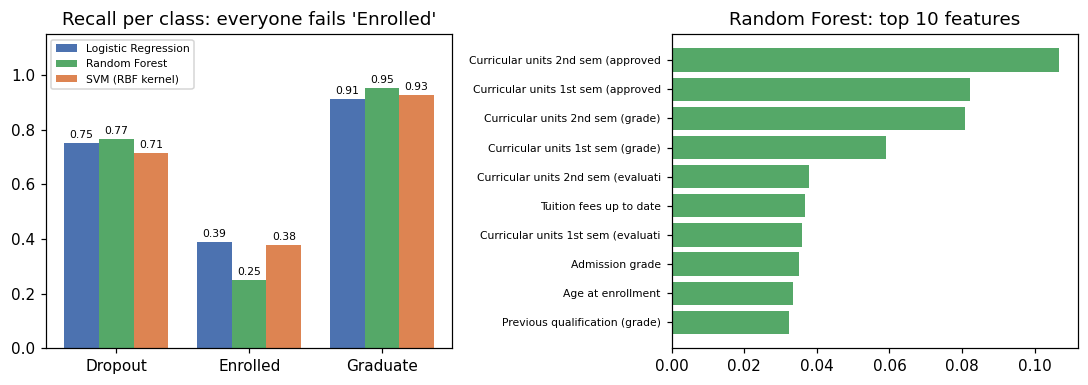

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
xx = np.arange(len(LABELS))
for i, (r, c) in enumerate(zip(results, colors)):
    b = ax[0].bar(xx + (i - 1) * w, r["rec_per"], w, label=r["name"], color=c)
    ax[0].bar_label(b, fmt="%.2f", padding=2, fontsize=7)
ax[0].set_xticks(xx, LABELS); ax[0].set_ylim(0, 1.15)
ax[0].set_title("Recall per class: everyone fails 'Enrolled'"); ax[0].legend(fontsize=7)

rf_model = rf["pipe"].named_steps["clf"]
feat_names = rf["pipe"].named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf_model.feature_importances_, index=feat_names).nlargest(10)
clean = [n.split("__", 1)[-1][:34] for n in imp.index][::-1]
ax[1].barh(clean, imp.values[::-1], color="#55A868")
ax[1].set_title("Random Forest: top 10 features"); ax[1].tick_params(axis="y", labelsize=7)
fig.tight_layout(); plt.show()

**The `Enrolled` column is the entire difference.** The Random Forest recovers only
**25.2%** of still-enrolled students against Logistic Regression's **39.0%**. The
forest quietly gives up on the hard minority class and banks the easy `Graduate` wins
instead (95.2% recall there, the best of the three). Because `Graduate` is half the
data, that trade costs it almost nothing in accuracy while gutting its macro F1. This
is exactly the failure that macro averaging is designed to expose.

**Cross-validation confirms it is not a fluke.** Logistic Regression leads on 5-fold
macro F1 (0.701) over the SVM (0.690) and the forest (0.672). The forest's deficit of
about 0.03 is roughly five times its own fold-to-fold spread, so this is a real gap,
not noise.

**The feature importances explain why simple wins.** The top features are dominated by
second and first semester units approved and grades. The relationship is close to
monotonic: pass more units, more likely to graduate. That is a pattern a **linear model
represents perfectly**, so the forest's extra flexibility has almost no real structure
left to find, and it spends that capacity overfitting instead.

### Strengths and weaknesses

**Logistic Regression** — *Strengths:* best macro F1 and best CV score here; fast;
gives calibrated probabilities; the coefficients are directly interpretable, which
matters when a university has to justify flagging a student. *Weaknesses:* can only
draw linear boundaries, so it would lose badly on genuinely non-linear data; needs
scaling; sensitive to correlated features.

**Random Forest** — *Strengths:* best `Dropout` recall (76.8%) and best `Graduate`
recall; no scaling needed; captures interactions automatically; hands you feature
importances for free, which is how we diagnosed this dataset. *Weaknesses:* worst macro
F1 here; abandoned the minority class; 300 trees are not interpretable individually;
slowest to train.

**SVM (RBF)** — *Strengths:* solid middle finisher, second on macro F1 and CV; strong
in high dimensions, which suits our 100+ encoded features; the margin gives good
generalisation. *Weaknesses:* no probabilities without extra cost; the most
scaling-dependent; `C` and `gamma` need tuning to shine; scales poorly to large data.

## Part D — Recommendation & Conclusion

**Recommendation: Logistic Regression.**

The evidence, all from the table and charts above:

1. **It has the best macro F1** on the held-out test set (0.693 against the SVM's 0.684
   and the forest's 0.663), and macro F1 is the right yardstick here because it refuses
   to let a model ignore the small `Enrolled` class.
2. **Cross-validation backs it up.** Its 5-fold macro F1 of 0.701 leads the SVM (0.690)
   and the forest (0.672), so the win survives resampling rather than resting on one
   lucky split.
3. **It handles the hard class best**, recovering 39.0% of `Enrolled` students against
   the forest's 25.2%.
4. **It is the most interpretable**, which is not a tiebreaker here but a real
   requirement. A university acting on these predictions has to be able to tell a
   student *why* they were flagged, and a coefficient does that where 300 trees cannot.

**The honest caveats.** Accuracy is a three-way tie in practice (0.767, 0.767, 0.761),
so on that metric alone none of this matters, which is precisely the lesson. And if the
goal were narrowly "catch as many likely dropouts as possible for early intervention",
the **Random Forest** would be the better pick, since its `Dropout` recall of 76.8%
edges Logistic Regression's 75.0%. The right model genuinely depends on which error you
are trying to avoid.

**Conclusion.** The most useful finding is that the **simplest model won**. The signal
in this data, pass your units and you graduate, is close to linear, so the forest's and
the SVM's extra flexibility bought nothing and the forest actively overfit. That is a
good reminder that model complexity is not a ladder you climb: it is a choice that
should match the shape of the data. All three models also agree on the deeper problem,
that `Enrolled` is genuinely ambiguous, since those students simply have not finished
yet, and no amount of model tuning will fix a label that the future has not decided.